In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'autompg-dataset' dataset.
Path to dataset files: /kaggle/input/autompg-dataset


In [3]:
from pathlib import Path
df=pd.read_csv(Path(path) / "auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [27]:
# Limpiar los datos antes de separar características y objetivo
df = df.drop(columns=["car name"], errors="ignore")
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].mean())

# Separar características y objetivo
X = df.drop(columns=["mpg"])
y = df["mpg"]

In [5]:
type(X)

pandas.core.frame.DataFrame

In [29]:
#dividir 80% train en X, y colocar la caracteristica mpg
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
df.isnull()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
393,False,False,False,False,False,False,False,False
394,False,False,False,False,False,False,False,False
395,False,False,False,False,False,False,False,False
396,False,False,False,False,False,False,False,False


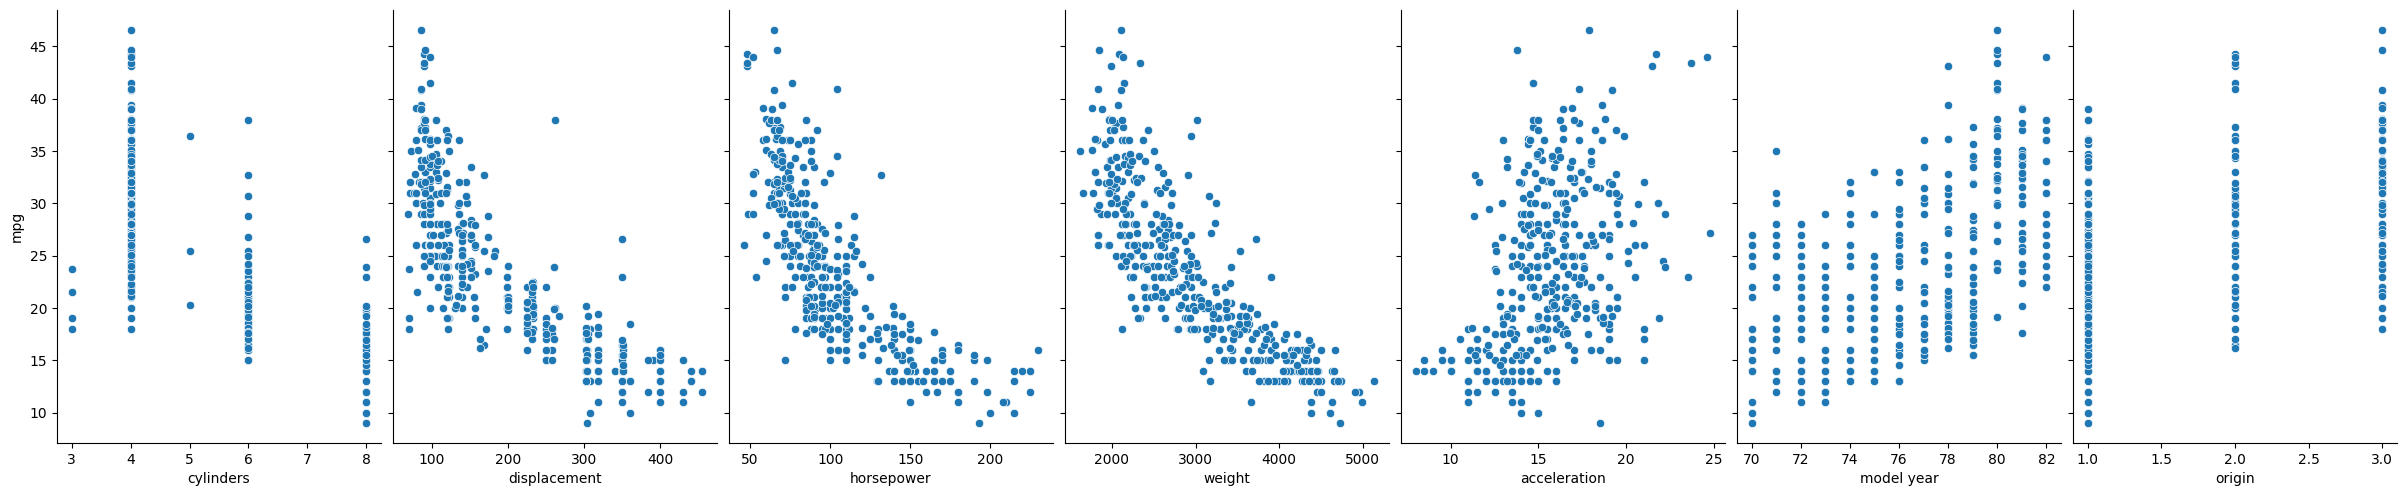

In [18]:
sns.pairplot(df, x_vars=["cylinders", "displacement", "horsepower", "weight", "acceleration", "model year", "origin"], y_vars=["mpg"], height=5, aspect=0.7, kind="scatter")

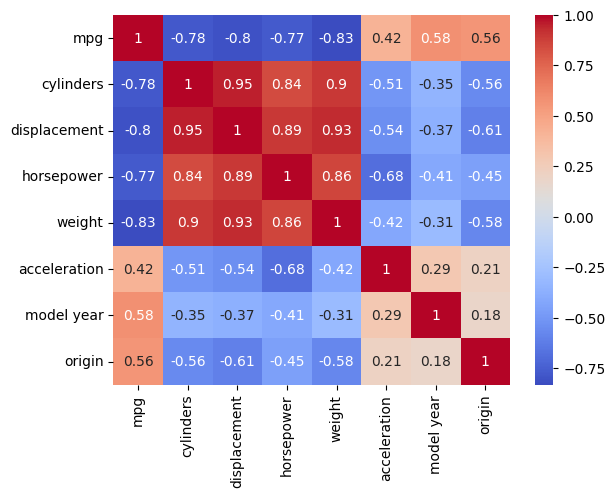

In [21]:
heatmap = sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

In [30]:
# Estandarizar las características usando solo el conjunto de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)